In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

pi = 95

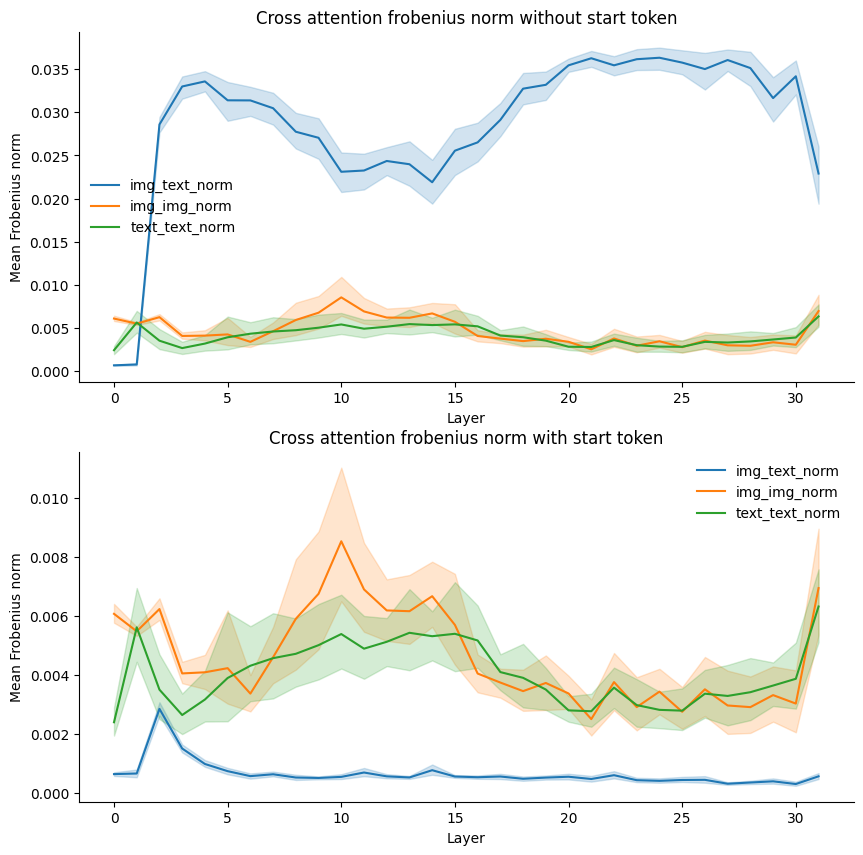

In [ ]:
fig,ax = plt.subplots(2,1,figsize=(10,10))
target = 'gray_cylinder_metal'
nobjects = 10

results_path = f'./results/llava7B/attention/image_and_text/frobenius_attention_matrix_{target}_{nobjects}_wstart_token.csv'
plot_df = pd.read_csv(results_path, index_col=0)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    # style='prompt',
    ax=ax[0] 
)

b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('Cross attention frobenius norm with start token')

results_path = f'./results/llava7B/attention/image_and_text/frobenius_attention_matrix_{target}_{nobjects}_wostart_token.csv'
plot_df = pd.read_csv(results_path, index_col=0)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    # style='prompt',
    ax=ax[1] 
)

b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('Cross attention frobenius norm without start token')


b.legend(frameon=False)
sns.despine(top=True, right=True)

In [42]:
attn_mat = np.load(f'./results/llava7B/attention/image_and_text/frobenius_attention_matrix_{target}_{nobjects}.npy')
attn_mat = np.log10(attn_mat)

/tmp/ipykernel_25501/2788562999.py:2: RuntimeWarning: divide by zero encountered in log10
  attn_mat = np.log10(attn_mat)


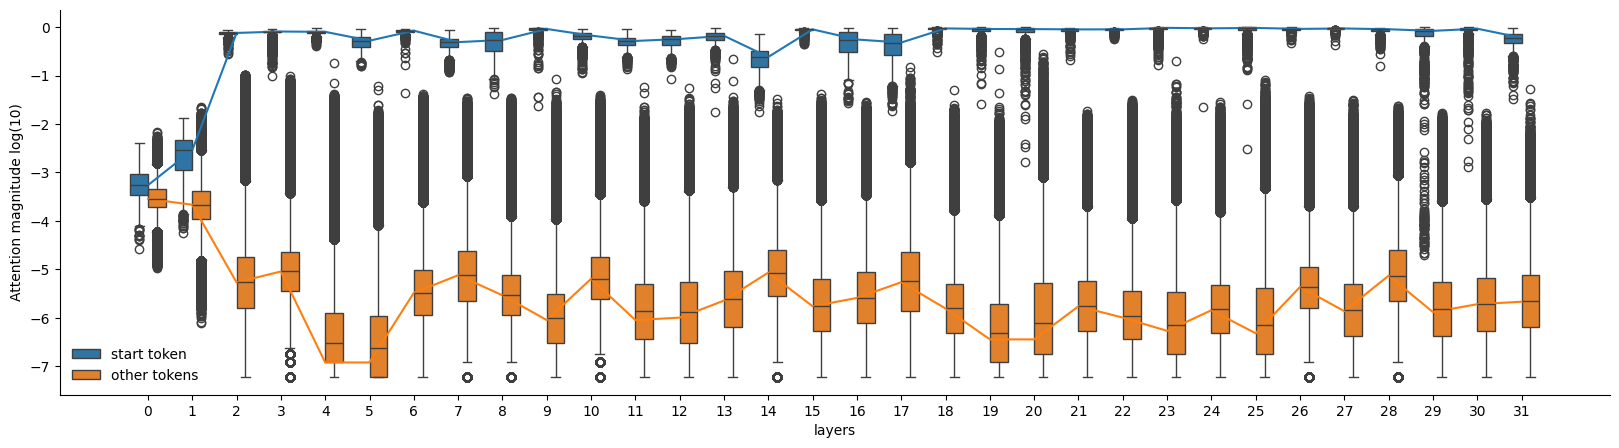

In [44]:
fig,ax = plt.subplots(1,1,figsize=(20, 5))
for i in range(attn_mat.shape[0]):
    plot_df = pd.DataFrame({
    'magnitude': np.append(attn_mat[i,0,:,0].reshape(-1),  attn_mat[i,0,:,1:].reshape(-1)),
    'layer': ['start token']*len(attn_mat[i,0,:,0].reshape(-1)) + ['other tokens']*len(attn_mat[i,0,:,1:].reshape(-1))
    })

    if i==0:
        b = sns.boxplot(data=plot_df,
                        x=i,
                        ax=ax,
                        y='magnitude',
                        hue='layer')
    else:
        b = sns.boxplot(data=plot_df,
                        x=i,
                        ax=ax,
                        legend=False,
                        y='magnitude',
                        hue='layer')
    b.legend(frameon=False)


plot_df = pd.DataFrame({
                        'magnitude': np.append(np.median(attn_mat[:,0,:,0], axis=1),  np.median(attn_mat[:,0,:,1:].reshape(attn_mat.shape[0],-1), axis=-1)),
                        'hue': ['start token']*len(np.median(attn_mat[:,0,:,0], axis=1)) + ['other tokens']*len(np.median(attn_mat[:,0,:,1:].reshape(attn_mat.shape[0],-1),axis=-1)),
                        'layer': list(range(len(attn_mat[:,0,:,0].mean(axis=1)))) + list(range(len(attn_mat[:,0,:,1:].reshape(attn_mat.shape[0],-1).mean(axis=-1))))
                        })
b=sns.lineplot(data=plot_df,y='magnitude',ax=ax,
                        x='layer', hue='hue', legend=False)
b.set_ylabel('Attention magnitude log(10)')
b.set_xlabel('layers')

sns.despine(top=True, right=True)
        

        
    


llava7B entropy auc:  0.0008594624681707637


llava7B fro auc:  0.0007196129956416275
llava1.6_vicuna entropy auc:  0.0009112894748771637
llava1.6_vicuna fro auc:  0.00020505031359021125
llava1.6_mistral entropy auc:  0.0009782597052442996
llava1.6_mistral fro auc:  0.00024815975979252926
gemma3-4B entropy auc:  0.0010374703783116146
gemma3-4B fro auc:  0.004260312216773976
gemma3-12B entropy auc:  0.0008672299448136841
gemma3-12B fro auc:  0.005578583156180132
qwen2.5_3B entropy auc:  0.0029646671153495644
qwen2.5_3B fro auc:  0.001013324121303146
qwen2.5_7B entropy auc:  0.0032221783204412465
qwen2.5_7B fro auc:  0.0008446235051839437


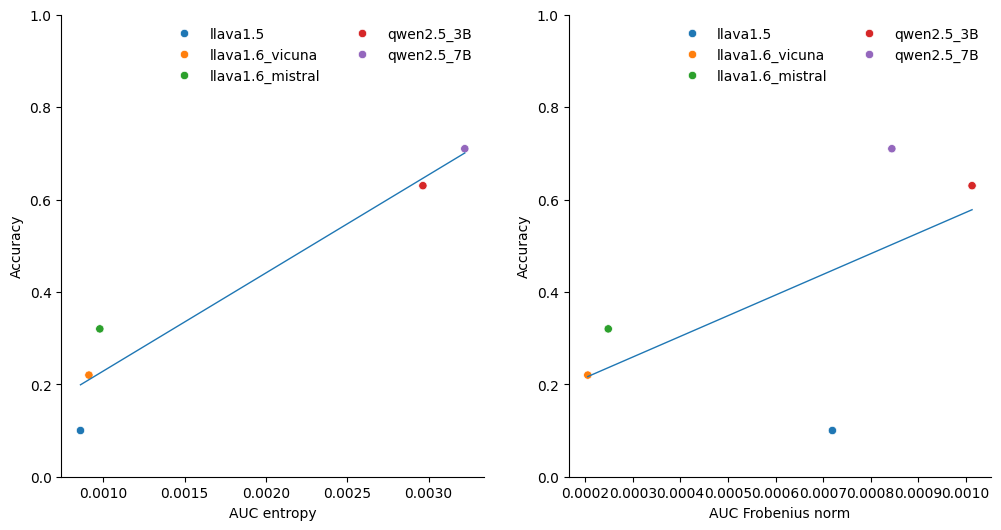

In [80]:
import sklearn
model_ls = ['llava7B', 'llava1.6_vicuna', 'llava1.6_mistral', 'gemma3-4B', 'gemma3-12B', 'qwen2.5_3B', 'qwen2.5_7B']
auc_entropy_ls = []
auc_fro_ls = []

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))

for ax_idx, model in enumerate(model_ls):
    path = f'./results/{model}/attention/'

    files_entropy = [i for i in os.listdir(path) if '.csv' in i and 'entropy' in i]
    files_fro = [i for i in os.listdir(path) if '.csv' in i and 'frobenius' in i]

    # Entropy
    plot_df = []
    for idx, f in enumerate(files_entropy):
        df_ = pd.read_csv(path+f, index_col=0)
        plot_df = plot_df + [df_]
    plot_df = pd.concat(plot_df).reset_index()
    mean_df = plot_df.groupby(["entropy", "variable"]).mean(numeric_only=True).reset_index()
    auc_text_img = sklearn.metrics.auc(mean_df[mean_df['entropy']=='img_text_entropy']['variable']/mean_df['variable'].max(), 
                                mean_df[mean_df['entropy']=='img_text_entropy']['value'])

    print(f"{model} entropy auc: ", auc_text_img)
    auc_entropy_ls = auc_entropy_ls + [auc_text_img]

    # Frobenius norm
    plot_df = []
    for idx, f in enumerate(files_fro):
        df_ = pd.read_csv(path+f, index_col=0)
        plot_df = plot_df + [df_]
    plot_df = pd.concat(plot_df).reset_index()
    mean_df = plot_df.groupby(["attention_matrix", "variable"]).mean(numeric_only=True).reset_index()
    auc_text_img = sklearn.metrics.auc(mean_df[mean_df['attention_matrix']=='img_text_norm']['variable']/mean_df['variable'].max(), 
                                mean_df[mean_df['attention_matrix']=='img_text_norm']['value'])

    print(f"{model} fro auc: ", auc_text_img)
    auc_fro_ls = auc_fro_ls + [auc_text_img]

acc_ls = [0.1, 0.22, 0.32, 0.47, 0.58, 0.63, 0.71]
model_ls = ['llava1.5', 'llava1.6_vicuna', 'llava1.6_mistral', 'gemma3-4B', 'gemma3-12B', 'qwen2.5_3B','qwen2.5_7B']
plot_df = pd.DataFrame({
    'model': model_ls,
    'Accuracy': acc_ls,
    'AUC': auc_entropy_ls
})
plot_df = plot_df[~plot_df['model'].str.contains('gemma')]
b = sns.scatterplot(data=plot_df, x='AUC', y='Accuracy', hue='model',ax=ax[0])
sns.regplot(data=plot_df, x="AUC", y="Accuracy", ci=None,
            scatter=False, ax=b, line_kws={"lw":1})
b.set_xlabel('AUC entropy')
b.set_ylabel("Accuracy")
b.legend(frameon=False, ncols=2)
b.set(ylim=(0,1))


plot_df = pd.DataFrame({
    'model': model_ls,
    'Accuracy': acc_ls,
    'AUC': auc_fro_ls
})
plot_df = plot_df[~plot_df['model'].str.contains('gemma')]
b = sns.scatterplot(data=plot_df, x='AUC', y='Accuracy', hue='model',ax=ax[1])
sns.regplot(data=plot_df, x="AUC", y="Accuracy", ci=None,
            scatter=False, ax=b, line_kws={"lw":1})
b.set_xlabel('AUC Frobenius norm')
b.set_ylabel("Accuracy")
b.set(ylim=(0,1))
b.legend(frameon=False, ncols=2)

sns.despine(top=True, right=True)

llava7B entropy auc:  -0.002593116781433061 0.0008594624681707637 0.0034525792496038245
llava7B fro auc:  -0.0041442930663813165 0.0007196129956416275 0.004863906062022944
llava1.6_vicuna entropy auc:  -0.0004319315349118316 0.0009112894748771637 0.0013432210097889953
llava1.6_vicuna fro auc:  -0.010668742001203494 0.00020505031359021125 0.010873792314793705
llava1.6_mistral entropy auc:  -0.0013594115327265938 0.0009782597052442996 0.0023376712379708934
llava1.6_mistral fro auc:  -0.007691030899646741 0.00024815975979252926 0.007939190659439271
gemma3-4B entropy auc:  -0.0020263676612125906 0.0010374703783116146 0.0030638380395242052
gemma3-4B fro auc:  -0.007800830269402564 0.004260312216773976 0.01206114248617654
gemma3-12B entropy auc:  -0.001691870114896363 0.0008672299448136841 0.002559100059710047
gemma3-12B fro auc:  -0.006756458222071744 0.005578583156180132 0.012335041378251876
qwen2.5_3B entropy auc:  -0.0004052768536372325 0.0029646671153495644 0.003369943968986797
qwen2.5_

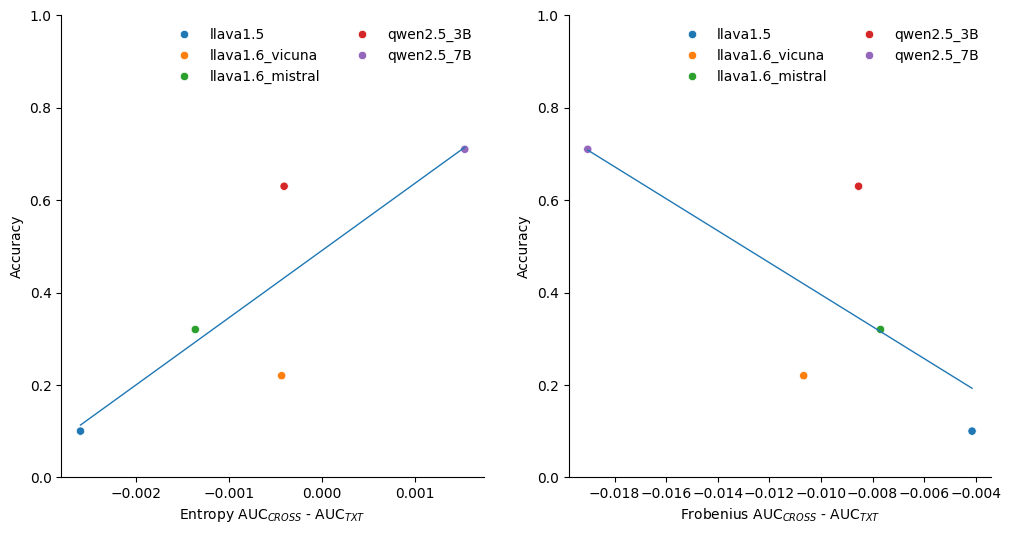

In [78]:
import sklearn
model_ls = ['llava7B', 'llava1.6_vicuna', 'llava1.6_mistral', 'gemma3-4B', 'gemma3-12B', 'qwen2.5_3B', 'qwen2.5_7B']
auc_entropy_ls = []
auc_fro_ls = []

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))

for ax_idx, model in enumerate(model_ls):
    path = f'./results/{model}/attention/'

    files_entropy = [i for i in os.listdir(path) if '.csv' in i and 'entropy' in i]
    files_fro = [i for i in os.listdir(path) if '.csv' in i and 'frobenius' in i]

    # Entropy
    plot_df = []
    for idx, f in enumerate(files_entropy):
        df_ = pd.read_csv(path+f, index_col=0)
        plot_df = plot_df + [df_]
    plot_df = pd.concat(plot_df).reset_index()
    mean_df = plot_df.groupby(["entropy", "variable"]).mean(numeric_only=True).reset_index()
    auc_cross = sklearn.metrics.auc(mean_df[mean_df['entropy']=='img_text_entropy']['variable']/mean_df['variable'].max(), 
                                mean_df[mean_df['entropy']=='img_text_entropy']['value'])
    
    auc_self =  sklearn.metrics.auc(mean_df[mean_df['entropy']=='text_text_entropy']['variable']/mean_df['variable'].max(), 
                                    mean_df[mean_df['entropy']=='text_text_entropy']['value'])

    print(f"{model} entropy auc: ", auc_cross - auc_self, auc_cross, auc_self)
    auc_entropy_ls = auc_entropy_ls + [auc_cross - auc_self]

    # Frobenius norm
    plot_df = []
    for idx, f in enumerate(files_fro):
        df_ = pd.read_csv(path+f, index_col=0)
        plot_df = plot_df + [df_]
    plot_df = pd.concat(plot_df).reset_index()
    mean_df = plot_df.groupby(["attention_matrix", "variable"]).mean(numeric_only=True).reset_index()
    auc_cross = sklearn.metrics.auc(mean_df[mean_df['attention_matrix']=='img_text_norm']['variable']/mean_df['variable'].max(), 
                                mean_df[mean_df['attention_matrix']=='img_text_norm']['value'])
    
    auc_self = sklearn.metrics.auc(mean_df[mean_df['attention_matrix']=='text_text_norm']['variable']/mean_df['variable'].max(), 
                                                mean_df[mean_df['attention_matrix']=='text_text_norm']['value'])

    print(f"{model} fro auc: ", auc_cross - auc_self, auc_cross, auc_self)
    auc_fro_ls = auc_fro_ls + [auc_cross - auc_self]

acc_ls = [0.1, 0.22, 0.32, 0.47, 0.58, 0.63, 0.71]
model_ls = ['llava1.5', 'llava1.6_vicuna', 'llava1.6_mistral', 'gemma3-4B', 'gemma3-12B', 'qwen2.5_3B','qwen2.5_7B']

plot_df = pd.DataFrame({
    'model': model_ls,
    'Accuracy': acc_ls,
    'AUC': auc_entropy_ls
})
plot_df = plot_df[~plot_df['model'].str.contains('gemma')]

b = sns.scatterplot(data=plot_df, x='AUC', y='Accuracy', hue='model',ax=ax[0])
sns.regplot(data=plot_df, x="AUC", y="Accuracy", ci=None,
            scatter=False, ax=b, line_kws={"lw":1})
b.set_xlabel('Entropy AUC$_{CROSS}$ - AUC$_{TXT}$')
b.set_ylabel("Accuracy")
b.legend(frameon=False, ncols=2)
b.set(ylim=(0,1))


plot_df = pd.DataFrame({
    'model': model_ls,
    'Accuracy': acc_ls,
    'AUC': auc_fro_ls
})
plot_df = plot_df[~plot_df['model'].str.contains('gemma')]
b = sns.scatterplot(data=plot_df, x='AUC', y='Accuracy', hue='model',ax=ax[1])
sns.regplot(data=plot_df, x="AUC", y="Accuracy", ci=None,
            scatter=False, ax=b, line_kws={"lw":1})
b.set_xlabel('Frobenius AUC$_{CROSS}$ - AUC$_{TXT}$')
b.set_ylabel("Accuracy")
b.set(ylim=(0,1))
b.legend(frameon=False, ncols=2)


sns.despine(top=True, right=True)

llava1.5, diff, 99.81303349332758
llava1.5, cross_modal, 16.133822134544
llava1.6_vicuna, diff, 96.18224637299241
llava1.6_vicuna, cross_modal, 22.286462972325346
llava1.6_mistral, diff, 10.187130386998323
llava1.6_mistral, cross_modal, 19.282819285328763
qwen2.5_3B, diff, 5.0269217791888945
qwen2.5_3B, cross_modal, 6.757314616126329
qwen2.5_7B, diff, 5.190159001721608
qwen2.5_7B, cross_modal, 7.349114629691261


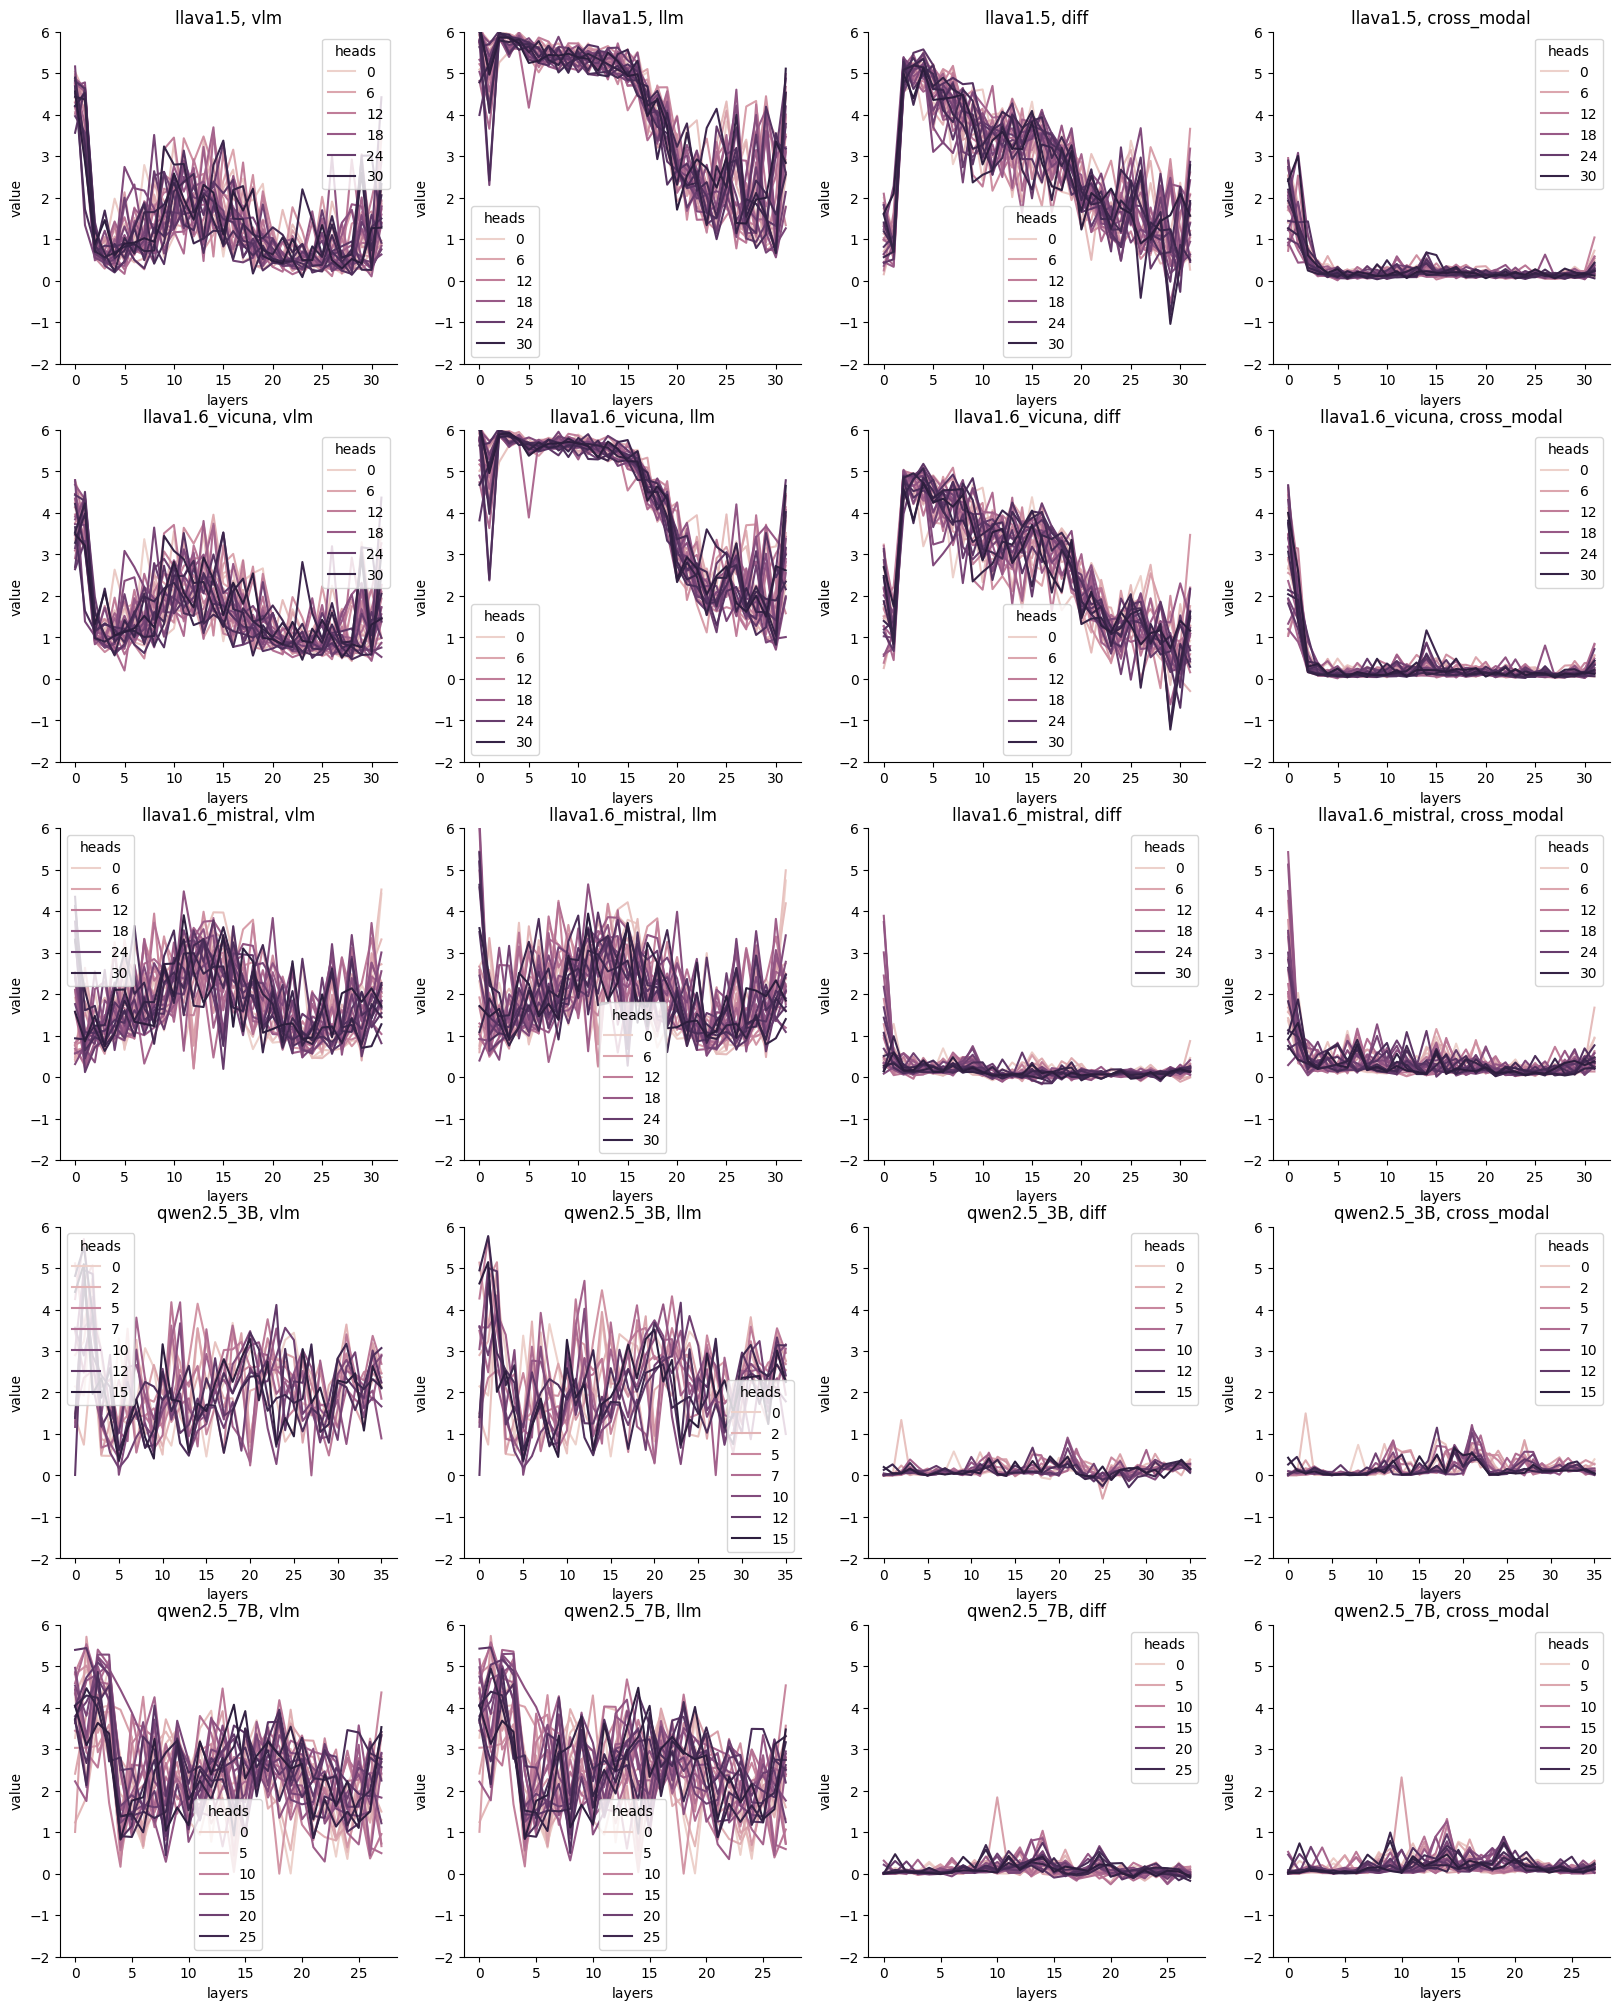

In [7]:
model_ls = ['llava1.5', 'llava1.6_vicuna', 'llava1.6_mistral', 'qwen2.5_3B', 'qwen2.5_7B']
matrix_ls = ['vlm', 'llm', 'diff', 'cross_modal']

fig,ax= plt.subplots(nrows=len(model_ls), ncols=len(matrix_ls), figsize=(5*len(matrix_ls),5*len(model_ls)))

for idx, model in enumerate(model_ls):
    df = pd.read_csv(f'./results/{model}/attention/entropy_diff_image_and_text_gray_cylinder_7.csv',index_col=0)
    for jdx, mat in enumerate(matrix_ls):

        plot_df = df[df['matrix']==mat]
        b = sns.lineplot(
            data=plot_df,
            x='layers',
            y='value',
            hue='heads',
            errorbar=("pi", pi),
            # style='prompt',
            ax=ax[idx][jdx],
        )
        b.set_title(f'{model}, {mat}')
        b.set(ylim=(-2,6))

        if mat=='diff' or mat=='cross_modal':
            print(f"{model}, {mat}, {np.linalg.norm(plot_df['value'],ord=2)}")

        # b = sns.heatmap(
        #     data=plot_df[['value', 'heads', 'layers']].pivot(index='heads', columns='layers'),
        #     ax=ax[1][jdx] 
        # )
        # b.set_title(mat)


sns.despine(top=True, right=True)

array(['vlm', 'llm', 'diff'], dtype=object)